# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [11]:
import random

import numpy as np
import matplotlib.pyplot as plt

from scripts.data_utils import load_CIFAR10

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [12]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
    del X_train, y_train
    del X_test, y_test
    print('Clear previously loaded data.')
except NameError:
    pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape:   ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape:       ', X_test.shape)
print('Test labels shape:     ', y_test.shape)


Clear previously loaded data.
Training data shape:    (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:        (10000, 32, 32, 3)
Test labels shape:      (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



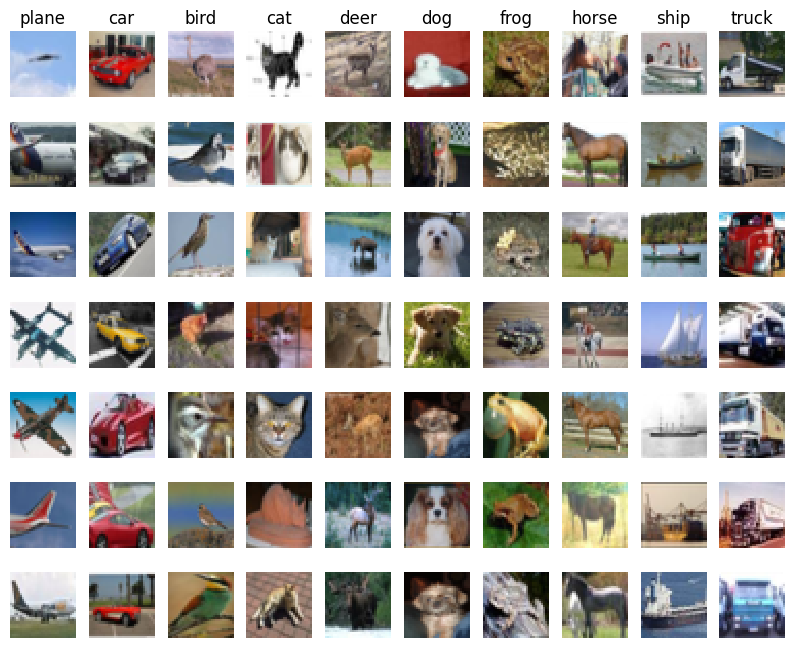

In [13]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

for cls_idx, cls_name in enumerate(classes):
    class_idxs = np.flatnonzero(y_train == cls_idx)
    class_idxs = np.random.choice(class_idxs, samples_per_class, replace=False)

    for row, idx in enumerate(class_idxs):
        plt_idx = row * num_classes + cls_idx + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if row == 0:
            plt.title(cls_name)

plt.show()


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [14]:
num_training = 5000
num_test = 500

X_train = X_train[:num_training]
y_train = y_train[:num_training]
X_test = X_test[:num_test]
y_test = y_test[:num_test]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print(X_train.shape, X_test.shape)


(5000, 3072) (500, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [15]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)


1.5 Выполните классификацию на тестовой выборке

In [ ]:
dists_no_loops = classifier.compute_distances_no_loops(X_test)
y_test_pred = classifier.predict_labels(dists_no_loops, k=1)

dists_one_loop = classifier.compute_distances_one_loop(X_test)
y_test_pred_one_loop = classifier.predict_labels(dists_one_loop, k=1)

dists_two_loops = classifier.compute_distances_two_loops(X_test)
y_test_pred_two_loops = classifier.predict_labels(dists_two_loops, k=1)


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


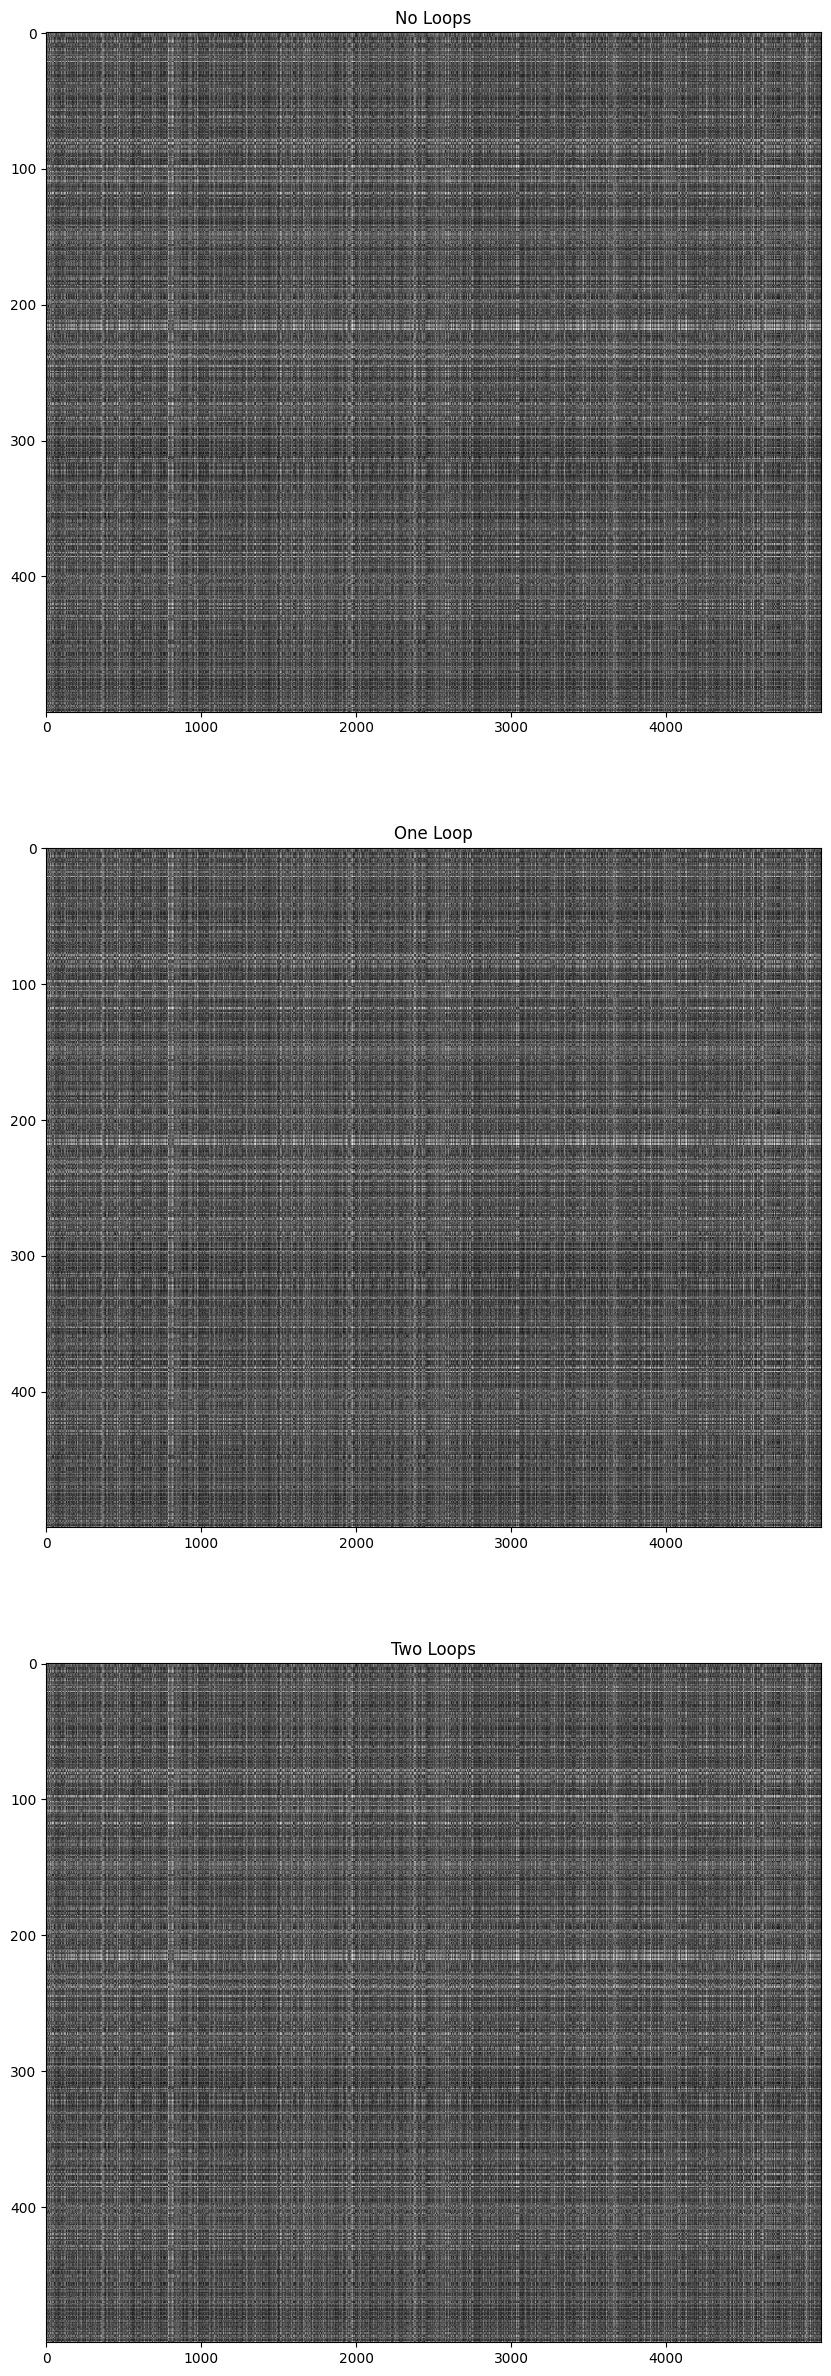

In [ ]:
plt.figure(figsize=(10, 30))

for sp_idx, (title, dists) in enumerate([
        ('No Loops', dists_no_loops),
        ('One Loop', dists_one_loop),
        ('Two Loops', dists_two_loops)], start=1):
    plt.subplot(3, 1, sp_idx)
    plt.imshow(dists, interpolation='none', aspect='auto')
    plt.title(title)

plt.show()



1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [18]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('%d/%d correct, accuracy = %f' % (num_correct, num_test, accuracy))


137/500 correct, accuracy = 0.274000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1, accuracy = 0.274
k = 3, accuracy = 0.272
k = 5, accuracy = 0.278
k = 7, accuracy = 0.274
k = 10, accuracy = 0.282
k = 12, accuracy = 0.256
k = 15, accuracy = 0.272
k = 20, accuracy = 0.272
k = 50, accuracy = 0.252
k = 100, accuracy = 0.222


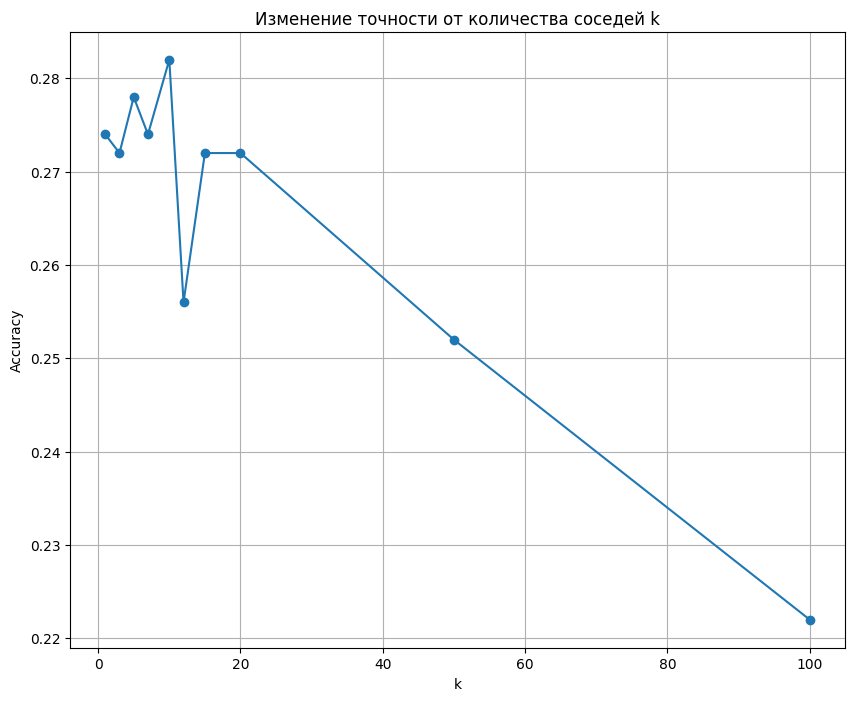

In [19]:
k_choices = [1, 3, 5, 7, 10, 12, 15, 20, 50, 100]
accuracies = []

for k in k_choices:
    y_pred_k = classifier.predict_labels(dists_no_loops, k=k)
    accuracy_k = float(np.sum(y_pred_k == y_test)) / num_test
    accuracies.append(accuracy_k)
    print(f'k = {k}, accuracy = {accuracy_k}')

plt.plot(k_choices, accuracies, marker='o')
plt.title('Изменение точности от количества соседей k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [ ]:
num_folds = 5
k_choices = [1, 3, 5, 7, 10, 12, 15, 20, 50, 100]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {k: [] for k in k_choices}

for fold in range(num_folds):
    X_tr_cv = np.concatenate([X_train_folds[j] for j in range(num_folds) if j != fold])
    y_tr_cv = np.concatenate([y_train_folds[j] for j in range(num_folds) if j != fold])
    X_val_cv = X_train_folds[fold]
    y_val_cv = y_train_folds[fold]

    classifier.train(X_tr_cv, y_tr_cv)
    dists_cv = classifier.compute_distances_no_loops(X_val_cv)

    for k in k_choices:
        y_val_pred = classifier.predict_labels(dists_cv, k=k)
        k_to_accuracies[k].append(np.mean(y_val_pred == y_val_cv))

k_avg = {k: float(np.mean(accs)) for k, accs in k_to_accuracies.items()}
for k in k_choices:
    print(f'k = {k}, accuracy = {k_avg[k]:.4f}')

best_k = max(k_avg, key=k_avg.get)
print(f'\nЛучшее k = {best_k}, accuracy = {k_avg[best_k]:.4f}')


k = 1, accuracy = 0.2656
k = 3, accuracy = 0.2496
k = 5, accuracy = 0.2732
k = 7, accuracy = 0.2744
k = 10, accuracy = 0.2802
k = 12, accuracy = 0.2794
k = 15, accuracy = 0.2750
k = 20, accuracy = 0.2790
k = 50, accuracy = 0.2744
k = 100, accuracy = 0.2616

Лучшее k = 10, accuracy = 0.2802



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [21]:
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('accuracy = %f' % accuracy)


accuracy = 0.282000


1.11 Сделайте выводы по результатам 1 части задания.

Метод kNN показал точность около 28% на тестовой выборке. Это заметно лучше случайного угадывания (10%), но всё ещё низкий результат для классификации изображений.

При k=1 точность на тесте составила 27,4% — модель чувствительна к шуму в ближайшем соседе. Пятикратная кросс-валидация по сетке k = {1, 3, 5, 7, 10, 12, 15, 20, 50, 100} дала лучшее k=10 со средней accuracy 0,2802 на фолдах. Переобучение и тест с найденным k=10 показали accuracy 0,282 — небольшое, но стабильное улучшение относительно k=1.

Главный недостаток метода — медленная скорость на этапе предсказания: каждый тестовый объект сравнивается со всей обучающей выборкой. Разница между реализациями compute_distances (two_loops / one_loop / no_loops) подтверждает это: векторизованная версия даёт тот же результат в разы быстрее и критична при работе с большими данными.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [ ]:
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

X_val = X_train[num_training:num_training + num_validation]
y_val = y_train[num_training:num_training + num_validation]

X_train = X_train[:num_training]
y_train = y_train[:num_training]

X_test = X_test[:num_test]
y_test = y_test[:num_test]

dev_mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[dev_mask]
y_dev = y_train[dev_mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Train data shape:      ', X_train.shape)
print('Train labels shape:    ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape:', y_val.shape)
print('Test data shape:       ', X_test.shape)
print('Test labels shape:     ', y_test.shape)
print('Dev data shape:        ', X_dev.shape)
print('Dev labels shape:      ', y_dev.shape)


Train data shape:       (49000, 3072)
Train labels shape:     (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape: (1000,)
Test data shape:        (1000, 3072)
Test labels shape:      (1000,)
Dev data shape:         (500, 3072)
Dev labels shape:       (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


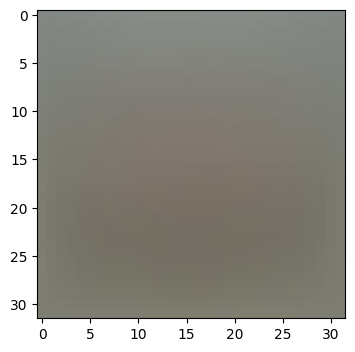

(49000, 3073) (1000, 3073) (1000, 3073)


In [ ]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])

plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((32, 32, 3)).astype('uint8'))
plt.show()

for arr_name in ('X_train', 'X_val', 'X_test', 'X_dev'):
    globals()[arr_name] = globals()[arr_name] - mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [ ]:
import time

from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized

W = np.random.randn(3073, 10) * 0.0001

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss,))


loss: 9.481065



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [ ]:
from scripts.gradient_check import grad_check_sparse

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)


numerical: 21.506055 analytic: 21.506055, relative error: 2.713179e-12
numerical: -7.587114 analytic: -7.587114, relative error: 2.662078e-11
numerical: 16.290349 analytic: 16.290349, relative error: 2.025374e-12
numerical: 1.265675 analytic: 1.265675, relative error: 1.120108e-10
numerical: -43.817848 analytic: -43.817848, relative error: 1.272780e-11
numerical: -42.828495 analytic: -42.828495, relative error: 2.832317e-12
numerical: -36.719381 analytic: -36.719381, relative error: 3.744345e-12
numerical: 1.164862 analytic: 1.164862, relative error: 8.215022e-11
numerical: 22.624714 analytic: 22.624714, relative error: 9.134005e-12
numerical: -0.459543 analytic: -0.459543, relative error: 7.222085e-10
numerical: -30.271967 analytic: -30.271967, relative error: 2.538787e-11
numerical: -23.916895 analytic: -23.916895, relative error: 2.108881e-12
numerical: 2.089361 analytic: 2.089361, relative error: 8.766727e-11
numerical: -0.465779 analytic: -0.465779, relative error: 2.292489e-10
nu

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [ ]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)


Naive loss and gradient: computed in 0.045891s
Vectorized loss and gradient: computed in 0.005334s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [27]:
from scripts.classifiers import LinearSVM

svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train,
                      learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))


iteration 0 / 1500: loss 786.035184
iteration 100 / 1500: loss 286.979948
iteration 200 / 1500: loss 107.868274
iteration 300 / 1500: loss 42.780353
iteration 400 / 1500: loss 19.331286
iteration 500 / 1500: loss 9.928618
iteration 600 / 1500: loss 6.895444
iteration 700 / 1500: loss 5.893012
iteration 800 / 1500: loss 5.603330
iteration 900 / 1500: loss 4.981949
iteration 1000 / 1500: loss 5.164535
iteration 1100 / 1500: loss 5.470915
iteration 1200 / 1500: loss 5.228564
iteration 1300 / 1500: loss 4.660761
iteration 1400 / 1500: loss 4.794883
That took 5.076701s


In [28]:
y_train_pred = svm.predict(X_train)
print('training accuracy:   %f' % (np.mean(y_train == y_train_pred),))

y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred),))


training accuracy:   0.370000
validation accuracy: 0.382000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [29]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

results = {}
best_val = -1
best_svm = None

for lr in learning_rates:
    for rs in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train,
                  learning_rate=lr, reg=rs,
                  num_iters=1500, verbose=False)

        train_accuracy = float(np.mean(svm.predict(X_train) == y_train))
        val_accuracy = float(np.mean(svm.predict(X_val) == y_val))
        results[(lr, rs)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, rs in sorted(results):
    train_accuracy, val_accuracy = results[(lr, rs)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f'
          % (lr, rs, train_accuracy, val_accuracy))

print('Best accuracy: %f' % best_val)


c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\scripts\classifiers\linear_svm.py:99: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\scripts\classifiers\linear_svm.py:99: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\scripts\classifiers\linear_svm.py:124: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
c:\Users\tssvett\OneDrive\Рабочий стол\ИИ2026\part2\scripts\classifiers\linear_svm.py:90: RuntimeWarning: invalid value encountered in dot
  scores = X.dot(W)


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.371061 val accuracy: 0.381000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.357939 val accuracy: 0.362000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.060224 val accuracy: 0.065000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.100265 val accuracy: 0.087000
Best accuracy: 0.381000


2.9 Сделайте выводы по второй части задания

Линейный SVM показал лучшую val-accuracy 38,1% (train 37,1%) при learning_rate=1e-7 и reg=2,5e4 — это выше, чем kNN. При этом на этапе предсказания SVM работает гораздо быстрее: одно матричное умножение X*W вместо попарных расстояний.

Сравнение naive и vectorized реализаций loss и градиента: разница нулевая (Frobenius norm = 0), векторизация даёт ускорение примерно на порядок (=0,046 с против =0,005 с на X_dev). Проверка градиента численным методом подтвердила корректность — относительная ошибка порядка 1e-10…1e-12.

Кросс-валидация по сетке learning_rate = {1e-7, 5e-5} и reg = {2,5e4, 5e4} показала, что модель крайне чувствительна к learning_rate: при lr=5e-5 обучение расходится (RuntimeWarning: overflow), точность падает до 6–9%, то есть хуже случайного угадывания. С корректным lr=1e-7 увеличение регуляризации с 2,5e4 до 5e4 ухудшило val-accuracy с 38,1% до 36,2%.

Несмотря на выигрыш у kNN, 38% недостаточно для практики: линейная модель не способна уловить нелинейные зависимости в пикселях.